In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']

from eval_CBD import Options, Trainer

import trimesh
from utils import ICT_face_model, YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)
import igl

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
config = f'{abs_path}/config/train_CBD.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.dec_type = 'disp'

## version 8
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-17-NGBCv8' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-19-NGBCv8' ## ------> 1 1

## version 5
# opts.ckpt = '../ckpts_CBD/2025-09-28-14-50-34-NGBCv5' ## ------> 1 1 softplus
# opts.ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-30-16-28-51-NGBCv5' ## ------> 1 1 none
# opts.ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# opts.ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
# opts.ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0
# opts.ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (soft POU)
# opts.ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
opts.ckpt = '../ckpts_CBD/2025-10-09-02-04-49-NGBCv5' ## ------> 1 1 (use_data2)

opts.in_type=1
opts.out_type=1

opts.num_cage_v=512
# opts.num_cage_v=128

opts.version=5
opts.last_activation='relu'
# opts.last_activation='none'

opts.no_pou=False

opts.use_data2=True
# opts.use_data2=False
opts.use_data3=False

trainer = Trainer(opts)

shape model not used!, use_shp_recon set to False
Loading... ../ckpts_CBD/2025-10-09-02-04-49-NGBCv5/model_best.pth


(23370, 3)
(11248, 3)


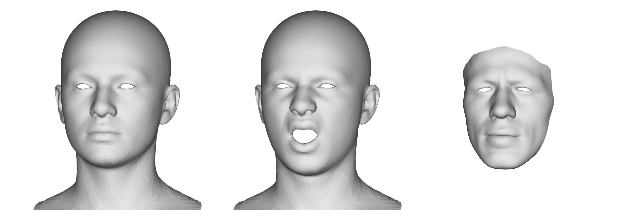

In [67]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
flame_tri = trimesh.load(f'{abs_path}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)

## ICT random expression
# bs_coeff = np.eye(53)[26]
bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26]*0.5
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [68]:
device=trainer.device
print(device)

sd_v = ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff).squeeze(0)
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(ict_tri.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(ict_tri.vertices, ict_tri.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, ict_tri.faces))[None].float().to(device)
t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)


cuda:0


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


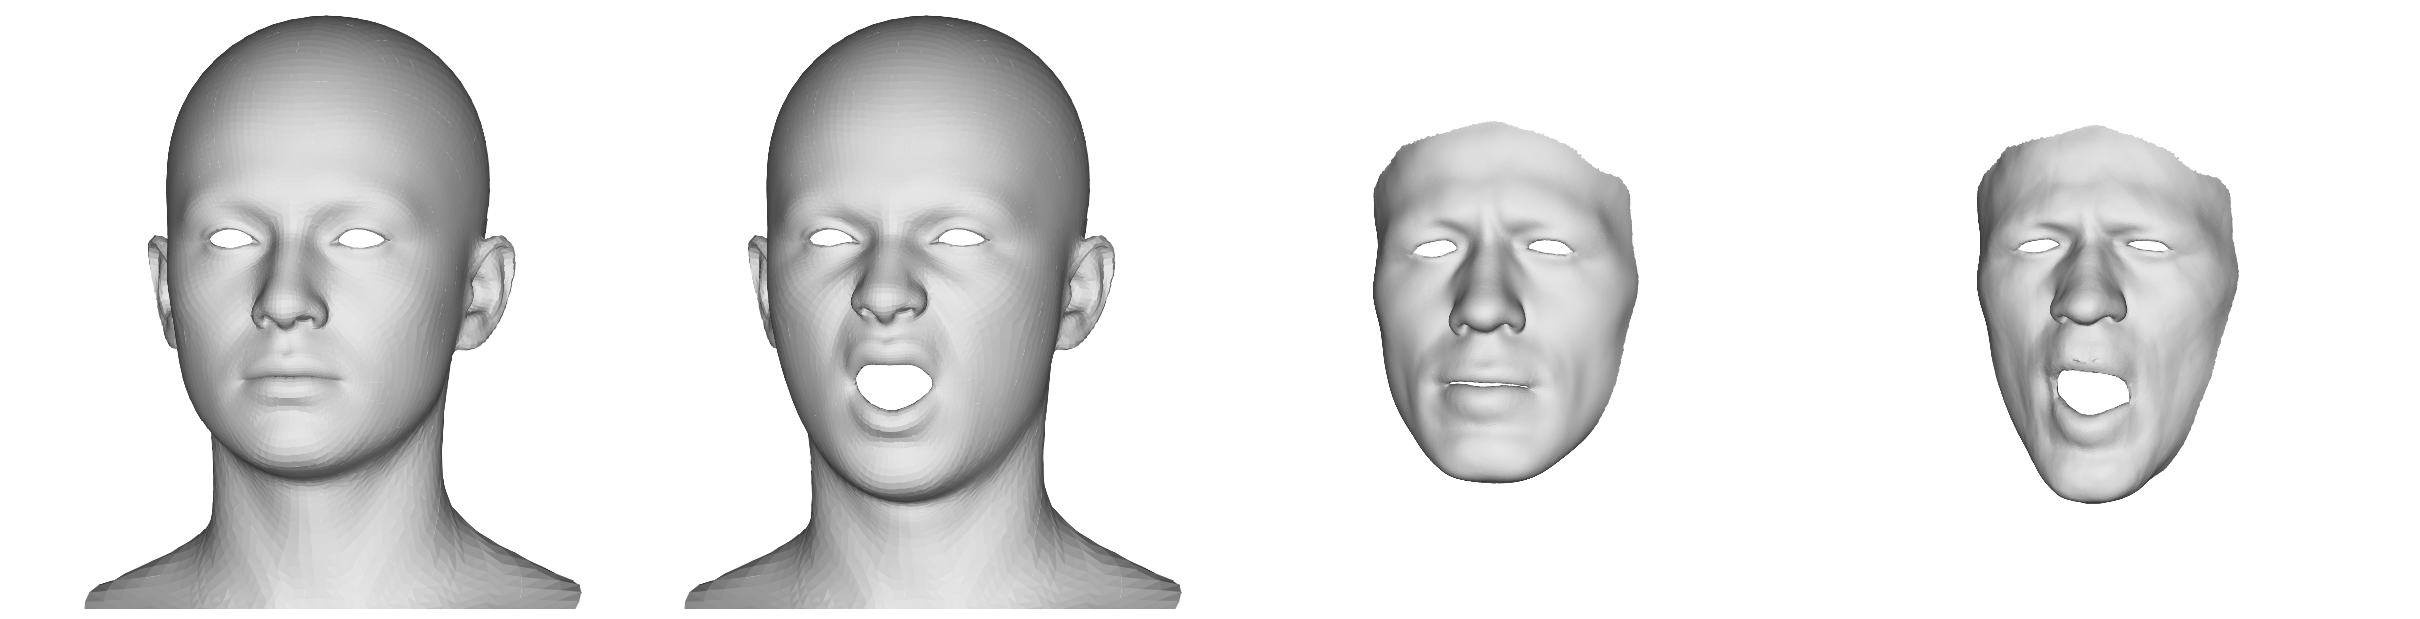

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


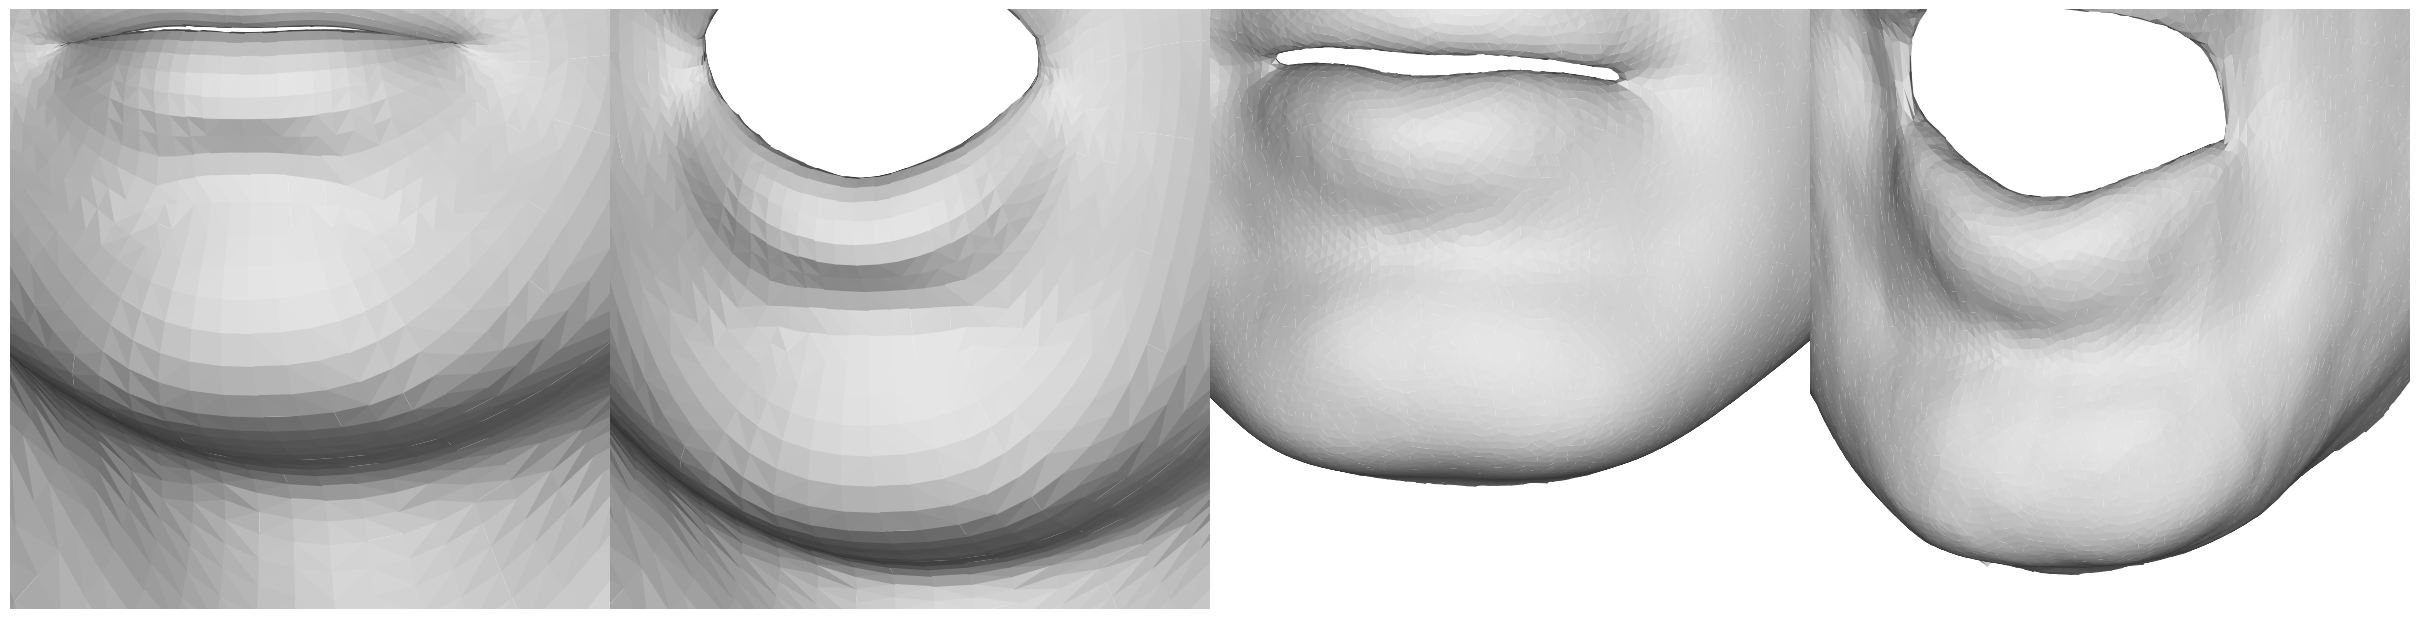

In [69]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.7
M_trns=np.array([0.1, 1.9, 0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget-zoom", save=SAVE
)

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


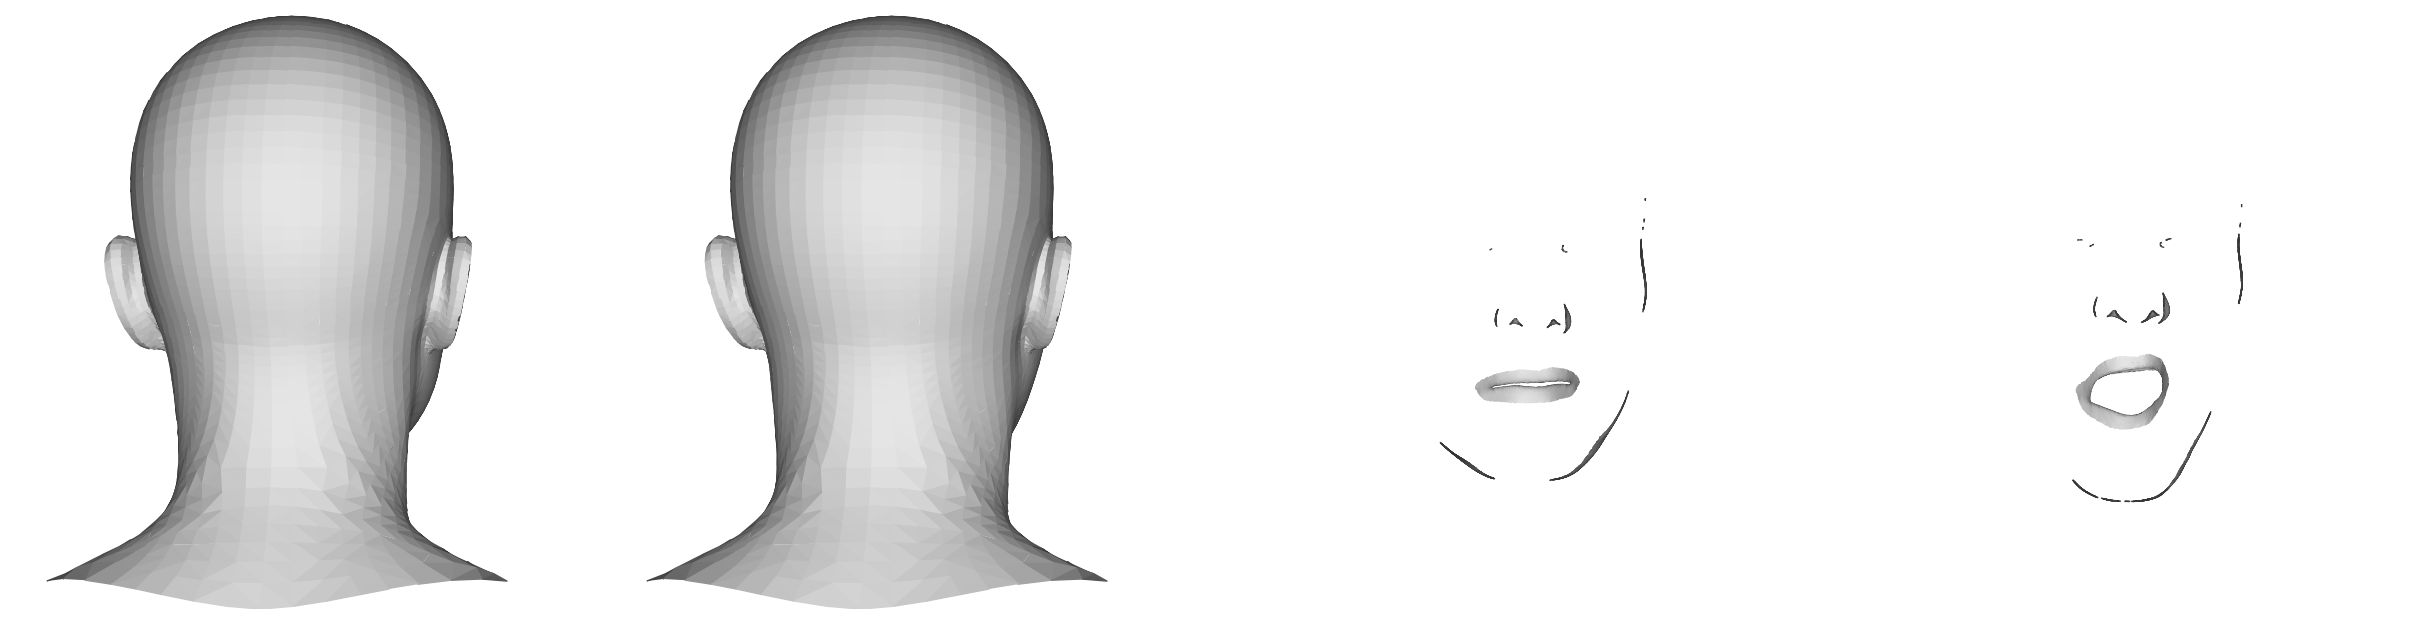

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


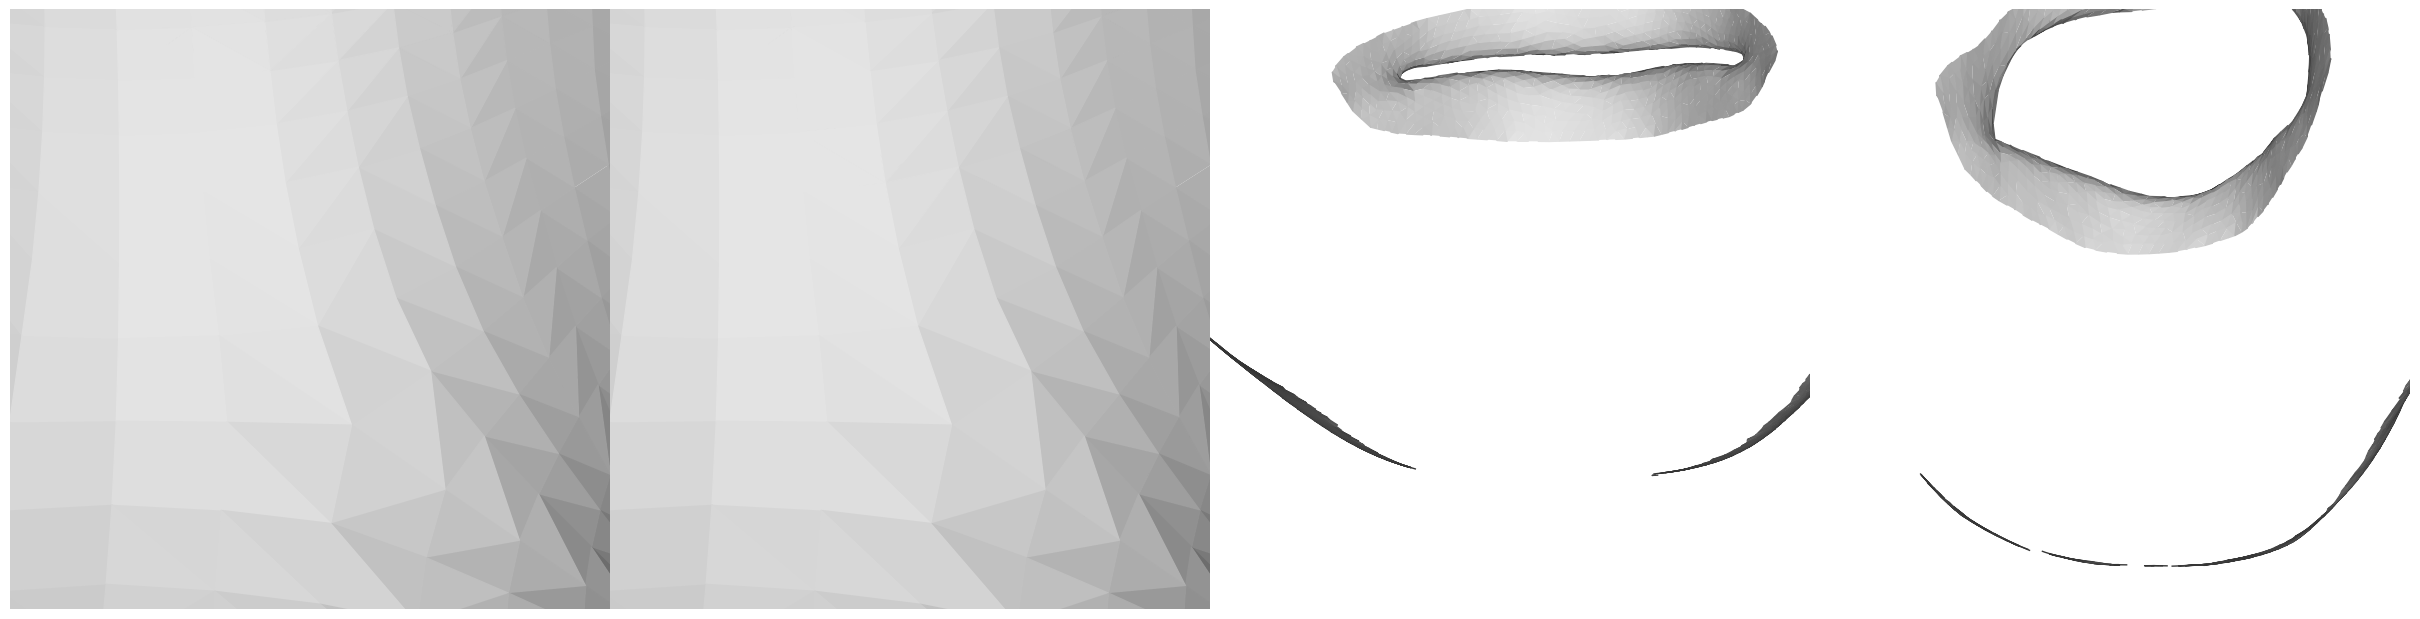

In [70]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-190,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.7
M_trns=np.array([0.1, 1.9, 0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-190,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget-zoom", save=SAVE
)